In [1]:
import pandas as pd

df = pd.read_csv('../data/creditcard.csv')
print(df.shape)
print(df.head())
print(df.info())
print(df['Class'].value_counts())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

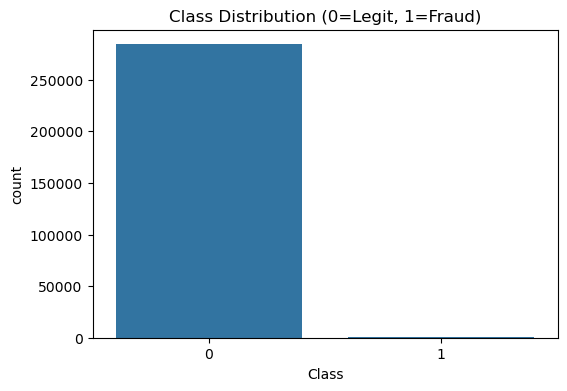

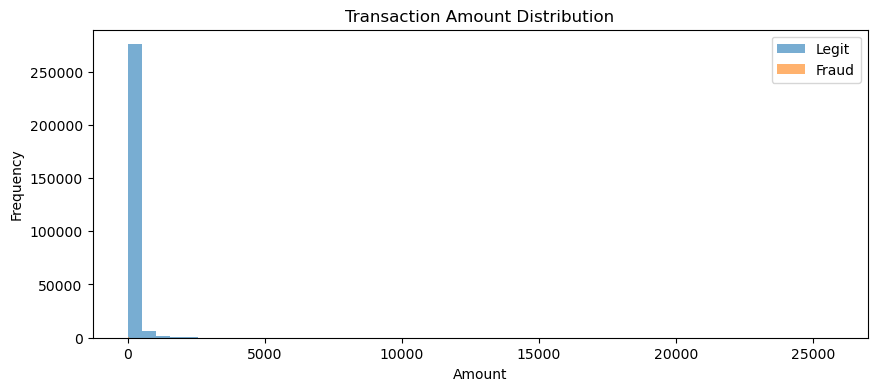

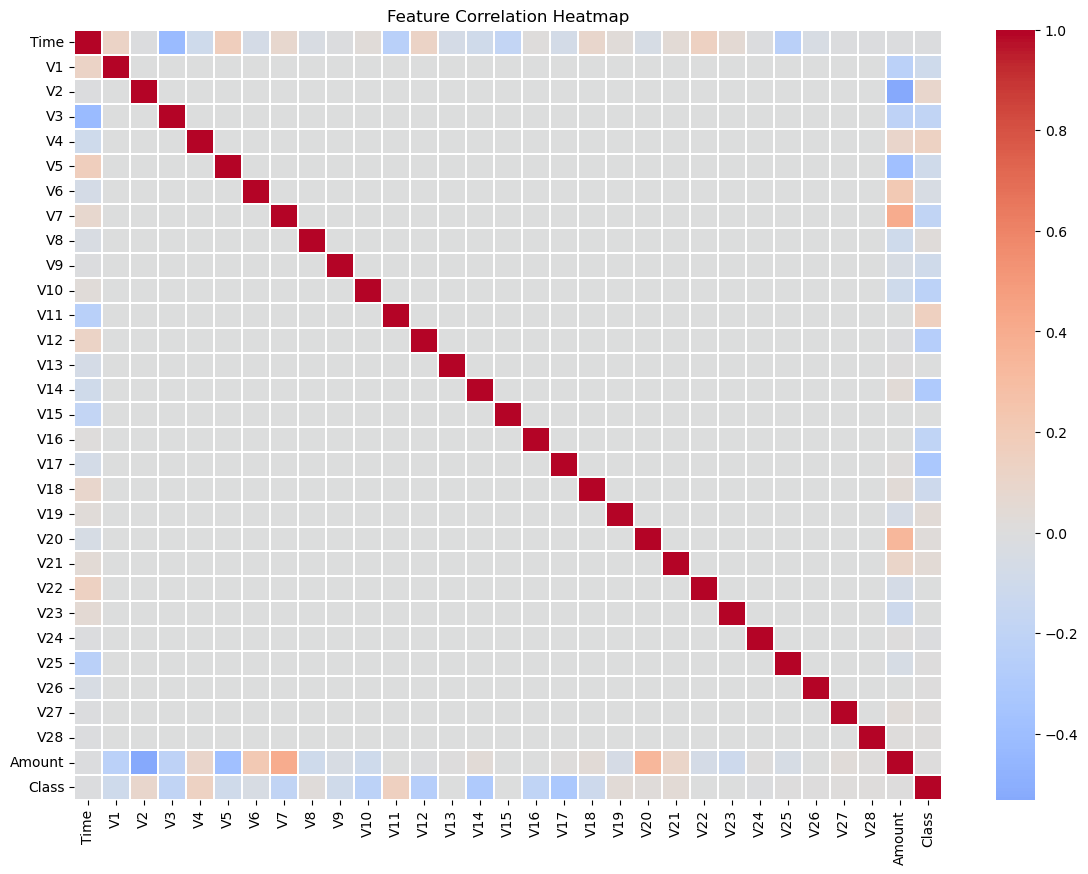

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.show()

# Amount distribution by class
plt.figure(figsize=(10,4))
df[df['Class']==0]['Amount'].plot(kind='hist', bins=50, alpha=0.6, label='Legit')
df[df['Class']==1]['Amount'].plot(kind='hist', bins=50, alpha=0.6, label='Fraud')
plt.legend()
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.show()

# Correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, linewidths=0.1)
plt.title('Feature Correlation Heatmap')
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Scale Amount and Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df_model = df.drop(columns=['Amount', 'Time'])

# Features and target
X = df_model.drop(columns=['Class'])
y = df_model['Class']

# Train/test split (80/20, stratified to preserve fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:", y_train.value_counts().to_dict())

# Apply SMOTE to training set only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_res.value_counts().to_dict())
print("X_train shape:", X_train_res.shape)

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}
X_train shape: (454902, 30)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)
lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print("ROC-AUC:", roc_auc_score(y_test, lr_proba))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698482164390798

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9688189076981384


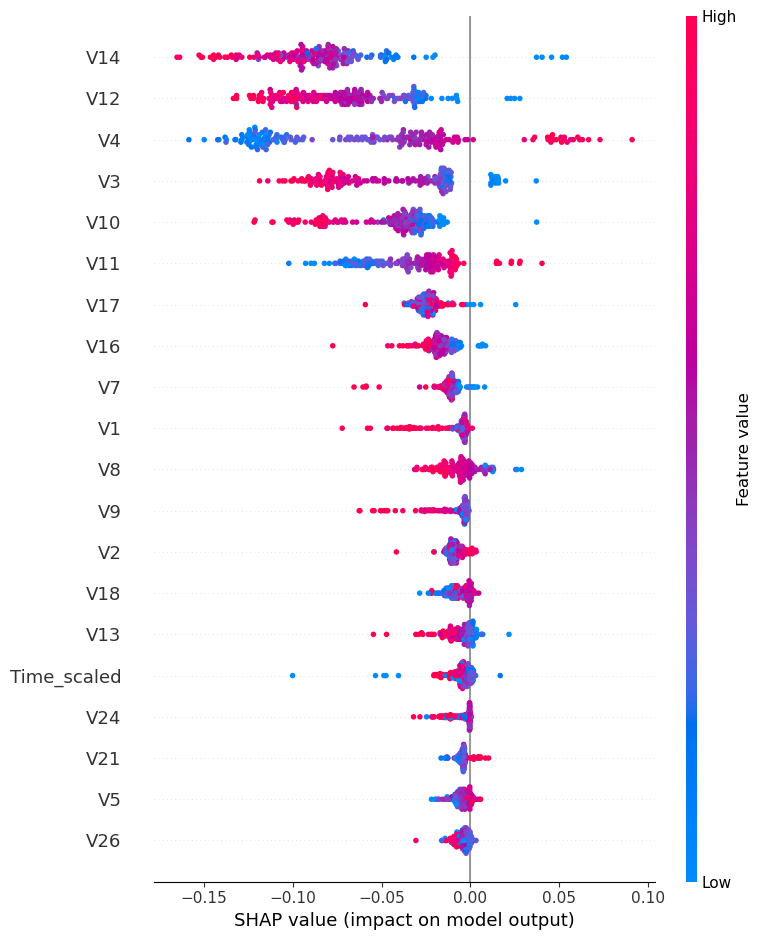

In [5]:
import shap

# Use a sample of test data (SHAP is slow on full dataset)
X_test_sample = X_test.sample(200, random_state=42)

# Build SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot — which features matter most overall
shap.summary_plot(shap_values[:,:,1], X_test_sample)

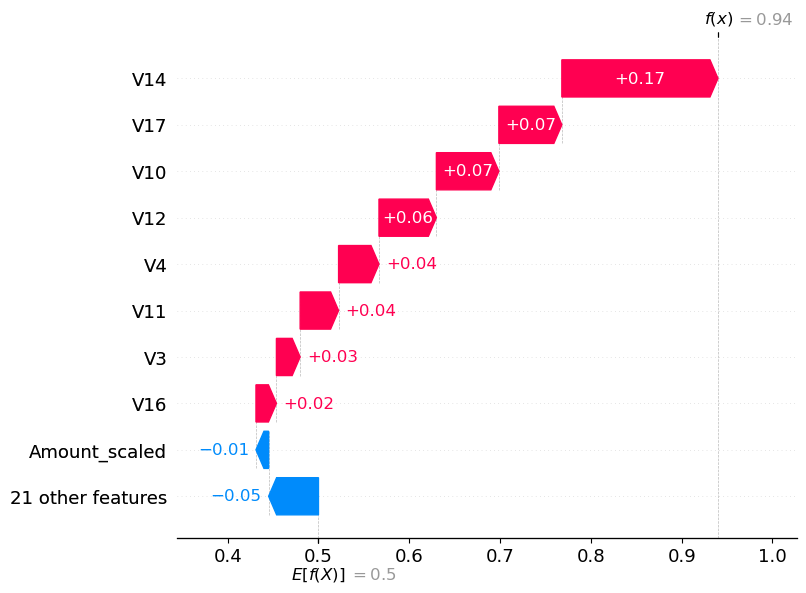

In [6]:
# Waterfall plot for a single fraudulent transaction
fraud_indices = X_test[y_test == 1].index
sample_fraud = X_test.loc[[fraud_indices[0]]]

shap_single = explainer.shap_values(sample_fraud)

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    shap_single[0][:,1],
    feature_names=X_test.columns.tolist()
)

In [9]:
from groq import Groq

import os
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

# Get SHAP values for the fraud sample
shap_vals = shap_single[0][:,1]
top_features = sorted(zip(X_test.columns, shap_vals), key=lambda x: abs(x[1]), reverse=True)[:5]
feature_summary = ", ".join([f"{f}: {v:.3f}" for f, v in top_features])

fraud_prob = rf.predict_proba(sample_fraud)[0][1]

prompt = f"""A transaction was flagged by a fraud detection model.
Fraud probability: {fraud_prob:.2%}
Top contributing features (SHAP values): {feature_summary}

Write a concise risk report (3-4 sentences) explaining why this transaction was flagged, the risk level, and a recommendation."""

response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

**Risk Report: High-Risk Transaction**

This transaction was flagged by our fraud detection model with a high fraud probability of 94.00%, indicating a significant risk of illegitimate activity. The top contributing features indicate that the following factors raised red flags: unusual transaction history (V14), recent activity from an unverified source (V17), and a high frequency of interactions with similar merchants (V10). Given these signs, we strongly recommend that the transaction be declined to prevent potential financial losses.


In [10]:
import joblib
joblib.dump(rf, '../notebooks/rf_model.pkl')
joblib.dump(scaler, '../notebooks/scaler.pkl')
print("Saved")

Saved


In [11]:
fraud_sample = df[df['Class']==1].iloc[0]
print(fraud_sample)

Time             406.000000
V1                -2.312227
V2                 1.951992
V3                -1.609851
V4                 3.997906
V5                -0.522188
V6                -1.426545
V7                -2.537387
V8                 1.391657
V9                -2.770089
V10               -2.772272
V11                3.202033
V12               -2.899907
V13               -0.595222
V14               -4.289254
V15                0.389724
V16               -1.140747
V17               -2.830056
V18               -0.016822
V19                0.416956
V20                0.126911
V21                0.517232
V22               -0.035049
V23               -0.465211
V24                0.320198
V25                0.044519
V26                0.177840
V27                0.261145
V28               -0.143276
Amount             0.000000
Class              1.000000
Amount_scaled     -0.353229
Time_scaled       -1.988034
Name: 541, dtype: float64


In [12]:
from sklearn.preprocessing import StandardScaler
scaler_amount = StandardScaler()
scaler_time = StandardScaler()
scaler_amount.fit(df[['Amount']])
scaler_time.fit(df[['Time']])
joblib.dump(scaler_amount, '../notebooks/scaler_amount.pkl')
joblib.dump(scaler_time, '../notebooks/scaler_time.pkl')
print("Saved")

Saved


In [15]:
X_train_no_time = X_train_res.drop(columns=['Time_scaled'])
X_test_no_time = X_test.drop(columns=['Time_scaled'])

rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train_no_time, y_train_res)

rf2_preds = rf2.predict(X_test_no_time)
rf2_proba = rf2.predict_proba(X_test_no_time)[:,1]

from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, rf2_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf2_proba))

joblib.dump(rf2, '../notebooks/rf_model.pkl')
print("Saved")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9830922221871304
Saved
